# CIBUSmod example
This notebook privides a step-by-step example of how the model is run and how outputs can be visualised. The model is currently a work in progress, so this notebook will be continuosly updated as the work progresses.

## Setting things up

### Import libraries
Add directory with the CIBUSmod modules to path to be able to import

In [1]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(),'..'))

Import CIBUSmod and packages for handling data and plotting

In [2]:
import CIBUSmod as cm
from CIBUSmod.utils.output_data_manip import concat_herds, get_GHG
import CIBUSmod.utils.plot as plot

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Run scenario 'Food as industry'

### Set up scenario and modules

Set path to folders containing all default and scenario data. We then give the session a name and define scenarios to model. Here we use a scenario defined in `data/scenarios/food_as_industry.xlsx` and calculate outputs for 5-year time-steps from 2020 to 2050.

In [3]:
# Create session
session = cm.Session(
    name = 'food_as_industry',
    data_path = '../data'
)

# Define scenarios
session.add_scenario(
    name = 'FAI',                                    # Name of scenario in outputs
    scenario = 'food_as_industry',                   # Name of scenario Excel file
    modules = 'all',                                 # Modules to update
    pars = 'all',                                    # Parameters to update
    years = [str(y) for y in range(2020,2050+1,10)]   # Years to calculate (= 2020-2050 with 10-year time-steps)
)

session.show_scenarios()

             scenario modules pars                     years
FAI  food_as_industry     all  all  [2020, 2030, 2040, 2050]


Next, we initialise all model modules (python classes) that handle the calculations.

Each module is intialised with a `ParameterRetriever` object which reads a named parameter Excel-file from the default data folder and handles the retrieval of parameter values used in the calculations. The `ParameterRetriever` also handles updating parameter values according to a scenario.

There are three main modules that store data as attributes (generaly in the form of pandas.DataFrames). These are:

`Regions`
<mark>W.I.P.</mark>

`DemandAndConversions`
This module calculates demand for crop and animal production based on population, consumption of different foods, waste and conversion factors, etc. It also calculates waste and by-products generated.

`CropProduction`
This module calculates production of crop products per unit (area) of a certain crop in a certain region.

`AnimalHerd`
This module has subclasses for each animal species (and breed) and is initialised as one AnimalHerd object per species (e.g. cattle) + breed (e.g. dairy) + production system (e.g. conventional) + sub system (used to represent different feeding strategies, e.g. maize based) combination. The `AnimalHerd` modules calculates production of animal products per animal unit (i.e. a defining animal in the species/breed). The defining animal differs accros species/breeds with e.g. 'cows' for `CattleHerd`s, 'sows+gilts' for `PigHerd`s and 'total horses' for `HorseHerd`s.

The there are also a number of management (mgmt) modules that calculates specific aspects on the main modules. These have no data attributes but do have their own parameter Excel-files connected to them. These are:

`FeedMgmt`
Handles the calculation of feed requirements, losses and import shares and the translation from 'feed products' to 'crop products' and 'by-products'.

`ManureMgmt`
Handles the calculation of manure excretion and losses in stables and storage.
<mark>Currently only nitrogen is implemented</mark>

`PlantNutrientMgmt`
Handles the calculation of crop fertiliser requirements and application of manure and mineral fertiliser.
<mark>Currently only nitrogen is handled</mark>

`MachineryAndEnergyMgmt`
Handles the calculation of energy requirements in machinery, drying, greenhouses, stables etc.
<mark>Energy use for grain drying not yet implemented</mark>

Finaly the module `GeoDistributor` handles the distribution of crop and animal production across regions by solving a convex optimisation problem that minimises the deviation of crop areas and animal numbers for the current situation while meeting demand for crop and animal products as wel as a number of additional constraints.

In [4]:
# Instatiate Regions
regions = cm.Regions(
    par = cm.ParameterRetriever('Regions')
)

# Instantiate DemandAndConversions
demand = cm.DemandAndConversions(
    par = cm.ParameterRetriever('DemandAndConversions')
)

# Instantiate CropProduction
crops = cm.CropProduction(
    par = cm.ParameterRetriever('CropProduction'),
    index = regions.x0_crops.index
)    

# Instantiate AnimalHerds
# Each AnimalHerd object is stored in an indexed pandas.Series
herds = cm.make_herds(regions)

# Instantiate feed management
feed_mgmt = cm.FeedMgmt(
    herds = herds,
    par = cm.ParameterRetriever('FeedMgmt')
)

# Instantiate manure management
manure_mgmt = cm.ManureMgmt(
    herds = herds,
    par = cm.ParameterRetriever('ManureMgmt')
)

# Instantiate plant nutrient management
plant_nutrient_mgmt = cm.PlantNutrientMgmt(
    demand = demand,
    regions = regions,
    crops = crops,
    herds = herds,
    par = cm.ParameterRetriever('PlantNutrientMgmt')
)

# Instatiate machinery and energy management
machinery_and_energy_mgmt  = cm.MachineryAndEnergyMgmt(
    regions = regions,
    crops = crops,
    herds = herds,
    par = cm.ParameterRetriever('MachineryAndEnergyMgmt')
)

# Instantiate geo distributor
geodist = cm.GeoDistributor(
    regions = regions,
    demand = demand,
    crops = crops,
    herds = herds,
    feed_mgmt = feed_mgmt,
    par = cm.ParameterRetriever('GeoDistributor')
)

### Run calculations
Now we have initialised all modules and can do the calculations. This is done by looping through scenarios and years and first updating all parameter values according to the speciefied scenario and year via `ParameterRetriever.update_all_parameter_values()` and then (re-)calculating all modules. After all modules a (re-)calculated we run `GeoDistributor.make()` and `GeoDistributor.solve()` to make and solve the optimisation problem that distribute crops and animals across regions. Finally ouputs are stored before the next iteration.

In [5]:
# Loop through scenarios
for scn in session.scenarios:
    scn_par = session.scenarios[scn].copy()
    years = scn_par.pop('years')
    
    # Loop through years
    for year in years:
        print(scn,year)

        # Update all parameter values
        cm.ParameterRetriever.update_all_parameter_values(
            **scn_par,
            year=year
        )

        # Get region attributes
        regions.calculate(verbose=True)

        # Calculate food demand
        demand.calculate(verbose=True)

        # Calculate crops
        crops.calculate(
            verbose = True
        )

        # Calculate herds
        for h in herds:
            h.calculate(verbose = True)

        # Calculate feed
        feed_mgmt.calculate(verbose=True)    

        # Distribute animals and crops
        # Make optimisation problem
        geodist.make(use_cons=[1,2,3,4,5,6,7], scale_power=0.6, verbose=True)
        # Solve optimisation problem
        geodist.solve(
            verbose=True,
            solver_settings = {
                'solver':'OSQP',
                'max_iter':200000,
                'eps_abs':5e-6,
                'eps_rel':5e-6,
                'verbose':False
            }
        )

        # Redistribute feeds (not yet implemented) and calculate enteric CH4 emissions
        feed_mgmt.calculate2(verbose=True)

        # Calculate manure
        manure_mgmt.calculate(verbose=True)

        # Calculate plant nutrient management
        plant_nutrient_mgmt.calculate(verbose=True)

        # Calculate energy requirements
        machinery_and_energy_mgmt.calculate(verbose=True)

        # Store results
        session.output.store(
            scn, year,
            demand, regions, crops, herds
        )

FAI 2020
[09:17:35][Regions] Getting initial crop areas and animal numbers (x0) ...
[09:17:35][Regions] Getting climate and soil attributes ...
[09:17:35][Regions] Calculating maximum land use ...
[09:17:35][Regions] Done! Elapsed time: 0 sec
[09:17:35][DemandAndConversions] Calculating food demand ...
[09:17:35][DemandAndConversions] Calculating waste ...
[09:17:35][DemandAndConversions] Calculating crop product demand ...
[09:17:35][DemandAndConversions] Calculating animal product demand ...
[09:17:36][DemandAndConversions] Done! Elapsed time: 1 sec
[09:17:36][CropProduction] Calculating harvest ...
[09:17:36][CropProduction] Calculating production ...
[09:17:38][CropProduction] Calculating crop residues ...
[09:17:38][CropProduction] Calculating seed demand ...
[09:17:39][CropProduction] Done! Elapsed time: 3 sec
[09:17:39][AnimalHerd (cattle, beef, conventional, maize based)] Calculating herd structure ...
[09:17:39][AnimalHerd (cattle, beef, conventional, maize based)] Calculating

[09:17:54][AnimalHerd (poultry, layer, organic, none)] Calculating production ...
[09:17:54][AnimalHerd (poultry, layer, organic, none)] Calculating feed energy or DM requirements ...
[09:17:54][AnimalHerd (poultry, layer, organic, none)] Done! Elapsed time: 1 sec
[09:17:54][FeedMgmt] Calculating feed consumption ...
[09:18:00][FeedMgmt] Calculating feed losses ...
[09:18:06][FeedMgmt] Calculating demand for crop products ...
[09:18:14][FeedMgmt] Calculating demand for by-products ...
[09:18:22][FeedMgmt] Done! Elapsed time: 28 sec
[09:18:22][GeoDistributor.make] Getting x0 and making indexes ...
[09:18:22][GeoDistributor.make] Creating demand vector ...
[09:18:23][GeoDistributor.make] Scaling ...
[09:18:23][GeoDistributor.make] Making objective O1 ...
[09:18:23][GeoDistributor.make] Making constraint C1 ...
[09:18:39][GeoDistributor.make] Making constraint C2 ...
[09:18:41][GeoDistributor.make] Making constraint C3 ...
[09:18:42][GeoDistributor.make] Making constraint C4 ...
[09:18:42

[09:20:35][AnimalHerd (horses, riding horses, organic, none)] Calculating feed energy or DM requirements ...
[09:20:35][AnimalHerd (horses, riding horses, organic, none)] Done! Elapsed time: 0 sec
[09:20:35][AnimalHerd (horses, trotters and racehorses, conventional, none)] Calculating herd structure ...
[09:20:35][AnimalHerd (horses, trotters and racehorses, conventional, none)] Calculating production ...
[09:20:35][AnimalHerd (horses, trotters and racehorses, conventional, none)] Calculating feed energy or DM requirements ...
[09:20:35][AnimalHerd (horses, trotters and racehorses, conventional, none)] Done! Elapsed time: 0 sec
[09:20:35][AnimalHerd (horses, trotters and racehorses, organic, none)] Calculating herd structure ...
[09:20:35][AnimalHerd (horses, trotters and racehorses, organic, none)] Calculating production ...
[09:20:35][AnimalHerd (horses, trotters and racehorses, organic, none)] Calculating feed energy or DM requirements ...
[09:20:36][AnimalHerd (horses, trotters and

[09:23:31][AnimalHerd (cattle, dairy, conventional, none)] Calculating production ...
[09:23:31][AnimalHerd (cattle, dairy, conventional, none)] Calculating feed energy or DM requirements ...
[09:23:32][AnimalHerd (cattle, dairy, conventional, none)] Done! Elapsed time: 1 sec
[09:23:32][AnimalHerd (cattle, dairy, organic, none)] Calculating herd structure ...
[09:23:32][AnimalHerd (cattle, dairy, organic, none)] Calculating production ...
[09:23:32][AnimalHerd (cattle, dairy, organic, none)] Calculating feed energy or DM requirements ...
[09:23:34][AnimalHerd (cattle, dairy, organic, none)] Done! Elapsed time: 2 sec
[09:23:34][AnimalHerd (horses, cold blooded horses, conventional, none)] Calculating herd structure ...
[09:23:34][AnimalHerd (horses, cold blooded horses, conventional, none)] Calculating production ...
[09:23:34][AnimalHerd (horses, cold blooded horses, conventional, none)] Calculating feed energy or DM requirements ...
[09:23:34][AnimalHerd (horses, cold blooded horses, 

[09:26:06][PlantNutrientMgmt] Calculating N soil losses ...
[09:26:06][PlantNutrientMgmt] Done! Elapsed time: 7 sec
[09:26:06][MachineryAndEnergyMgmt] Calculating energy use in field machinery ...
[09:26:10][MachineryAndEnergyMgmt] Calculating energy use for grain drying (not implemented) ...
[09:26:10][MachineryAndEnergyMgmt] Calculating energy use in greenhouses ...
[09:26:11][MachineryAndEnergyMgmt] Calculating energy use in stables ...
[09:26:29][MachineryAndEnergyMgmt] Calculating fuel use emissions ...
[09:26:30][MachineryAndEnergyMgmt] Done! Elapsed time: 24 sec
FAI 2050
[09:26:35][Regions] Getting initial crop areas and animal numbers (x0) ...
[09:26:35][Regions] Getting climate and soil attributes ...
[09:26:35][Regions] Calculating maximum land use ...
[09:26:35][Regions] Done! Elapsed time: 0 sec
[09:26:35][DemandAndConversions] Calculating food demand ...
[09:26:36][DemandAndConversions] Calculating waste ...
[09:26:36][DemandAndConversions] Calculating crop product demand 

[09:26:55][AnimalHerd (poultry, layer, conventional, none)] Calculating production ...
[09:26:56][AnimalHerd (poultry, layer, conventional, none)] Calculating feed energy or DM requirements ...
[09:26:56][AnimalHerd (poultry, layer, conventional, none)] Done! Elapsed time: 0 sec
[09:26:56][AnimalHerd (poultry, layer, organic, none)] Calculating herd structure ...
[09:26:56][AnimalHerd (poultry, layer, organic, none)] Calculating production ...
[09:26:56][AnimalHerd (poultry, layer, organic, none)] Calculating feed energy or DM requirements ...
[09:26:56][AnimalHerd (poultry, layer, organic, none)] Done! Elapsed time: 1 sec
[09:26:56][FeedMgmt] Calculating feed consumption ...
[09:27:03][FeedMgmt] Calculating feed losses ...
[09:27:09][FeedMgmt] Calculating demand for crop products ...
[09:27:17][FeedMgmt] Calculating demand for by-products ...
[09:27:26][FeedMgmt] Done! Elapsed time: 30 sec
[09:27:26][GeoDistributor.make] Getting x0 and making indexes ...
[09:27:26][GeoDistributor.make

## Save results to file
We can write outputs to a binary file using pickle for future use.

In [6]:
# Write file
# This may take a while depending the number of scenarios and years
session.save_output()

In [4]:
# Read file
session.read_output()

### Look at the data

Use `Session.output.info()` to get a summary of scenarios and modules and their data attributes.

In [5]:
session.output.info()

*-----------------*
| CIBUSmod Output |
*-----------------*

Scenarios
---------
FAI: 2020 --> 2050 (7 years)

DemandAndConversions
--------------------
Data attributes:
crop_by_products, non_food_demand, crop_prod_demand, animal_prod_demand, export_demand, food_demand_to_processing, population, waste, food_demand, animal_by_products


Regions
-------
Data attributes:
soil, x0_animals, x0_crops, climate, max_land_use


CropProduction
--------------
Data attributes:
fertiliser.manure_N, fertiliser.mineral_N, fertiliser.mineral_N_soil_loss, fertiliser.manure_N_soil_loss, fertiliser.manure_C, area, harvest, fertiliser.manure_TAN, fertiliser.TAN_req, production, energy_use_emissions, fertiliser.organic_soil_N_loss, seed_demand, production_per_use, harvest_dm, fertiliser.manure_N_application_loss, crop_residues, fertiliser.crop_residues_N, fertiliser.mineral_N_application_loss, energy_use, harvested_crop_residues, fertiliser.crop_residues_N_soil_loss


AnimalHerd
----------
Data attributes:

Use `Output.get_attr()` to retrieve specific data for all scenarios and years.

In [9]:
output.get_attr(
    module='c',
    attr='area',
    groupby='none'
)/1000

scn  year
FAI  2020    4221.069357
     2025    4443.536531
     2030    4567.895657
     2035    4683.173757
     2040    4796.942488
     2045    4909.872623
     2050    5015.210076
Name: area, dtype: float64

In [10]:
output.get_attr(
    module='A',
    attr='heads',
    groupby='species'
)/1000

species        cattle  horses         pigs       poultry
scn year                                                
FAI 2020  1547.169148   355.5  1418.474302  26054.070618
    2025  1632.880648   355.5  1489.920156  26962.437440
    2030  1699.615997   355.5  1546.085104  27664.987196
    2035  1745.812987   355.5  1585.496983  28141.316647
    2040  1775.931556   355.5  1611.885324  28465.527854
    2045  1788.185141   355.5  1623.548195  28610.651169
    2050  1777.298513   355.5  1615.892050  28500.720923

## Plot output
Here are some example output plots.

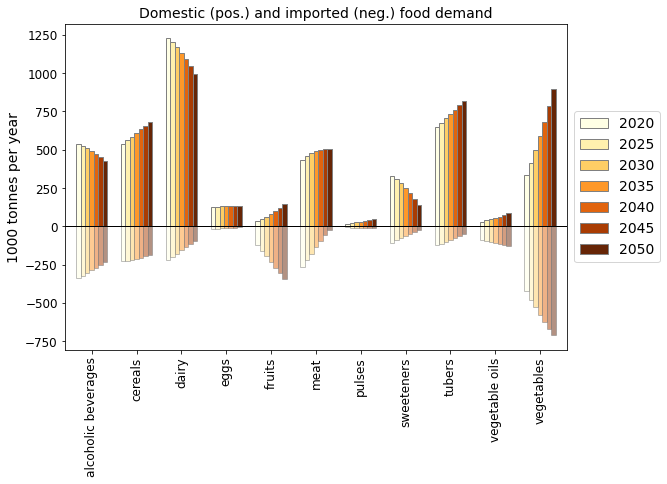

In [11]:
style = {
    'kind' : 'bar',
    'cmap' : 'YlOrBr',
    'edgecolor' : 'grey',
    'legend' : False,
    'width' : 0.7
}
plot_data = (
    output.get_attr(
        module='D',
        attr='food_demand_to_processing',
        groupby=['origin','food_group']
    )
    .stack()
    .droplevel('scn')
)/1000000
plot_data.loc[:,'imported'] = -plot_data.loc[:,'imported']

fig, ax = plt.subplots(figsize=(9,6))
plot_data['domestic'].unstack('year').plot(**style, ax=ax)
(
    plot_data['imported'].unstack('year')
    .rename({x:'_' for x in plot_data.index.get_level_values('year').unique()}, axis=1)
).plot(**style, ax=ax, alpha=0.5)

plt.hlines(0,-1,11, color='black', linewidth=1)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_ylabel('1000 tonnes per year', size=14)
ax.set_title('Domestic (pos.) and imported (neg.) food demand', size=14)
ax.set_xlabel('')
ax.legend(loc='center left', ncol=1, bbox_to_anchor=(1, 0.5), fontsize=14)

# plt.tight_layout()
plt.show()

FAI


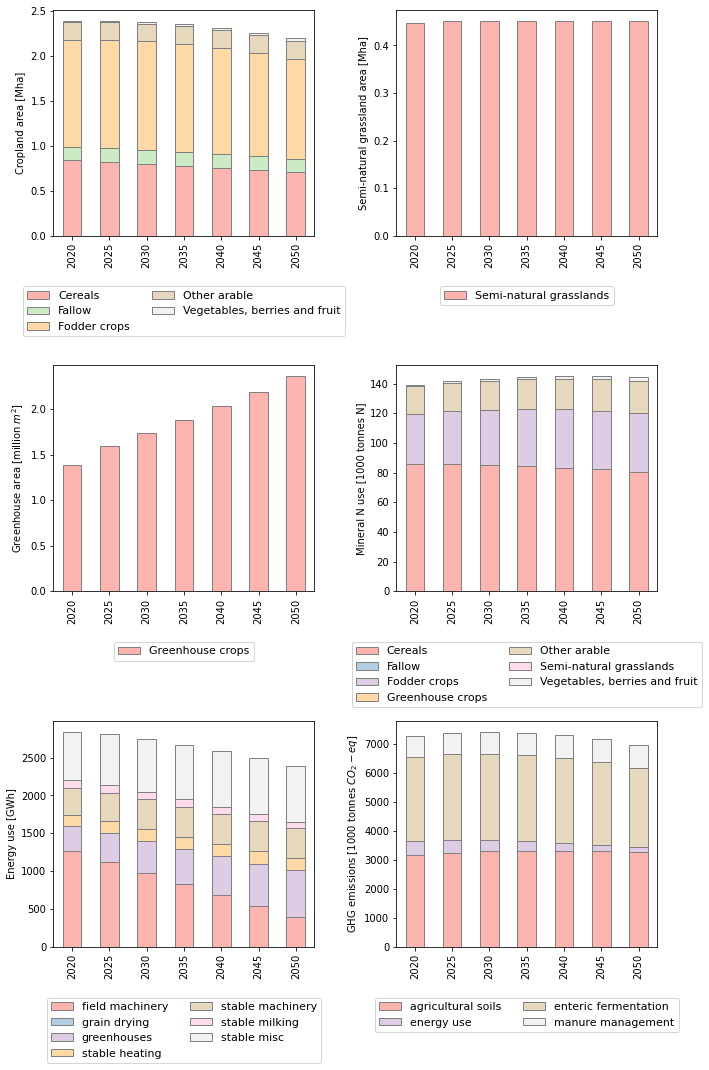

In [11]:
for scn in scenarios:
    print(scn)

    fig, axs = plt.subplots(3,2, figsize=(10,15))

    # Land use --->
    plot_data = output.get_attr('C','area',{'crop':'crop_group2'}).loc[scn]/1000000
    
    # Cropland
    ax = axs[0,0]
    plot_data.drop(['Semi-natural grasslands','Greenhouse crops'], axis=1).plot(**style, ax=ax)
    ax.set_ylabel('Cropland area [Mha]')
    
    # Semi-natural grassland
    ax = axs[0,1]
    plot_data.xs('Semi-natural grasslands', axis=1).plot(**style, ax=ax)
    ax.set_ylabel('Semi-natural grassland area [Mha]')
    
    # Greenhouse
    ax = axs[1,0]
    plot_data.xs('Greenhouse crops', axis=1).plot(**style, ax=ax)
    ax.set_ylabel(r'Greenhouse area [million $m^2$]')

    # Mineral N use --->
    ax = axs[1,1]
    (output.get_attr('C','fertiliser.mineral_N',{'crop':'crop_group2'})/1000000).loc[scn].plot(**style, ax=ax)
    ax.set_ylabel('Mineral N use [1000 tonnes N]')

    # Energy use --->
    ax = axs[2,0]
    pd.concat([
        output.get_attr('C','energy_use','activity').loc[scn]/1000000,
        output.get_attr('A','energy_use','activity').loc[scn]/1000000
    ], axis=1).plot(**style, ax=ax)
    ax.set_ylabel('Energy use [GWh]')
    
    # GHG emissions
    ax = axs[2,1]
    plot_data = (get_GHG(output).sum()/1000000).loc[scn]
    (
        plot_data
        .groupby(['year','process'])
        .sum()
        .unstack()
    ).plot(**style, ax=ax)
    ax.set_ylabel(r'GHG emissions [1000 tonnes $CO_{2}-eq$]')
    
    for ax in axs.flatten():
        ax.legend(loc='upper center', ncol=2, bbox_to_anchor=(0.5, -0.2), fontsize=11)
        ax.set_xlabel('')

    fig.tight_layout()
    plt.show()

FAI


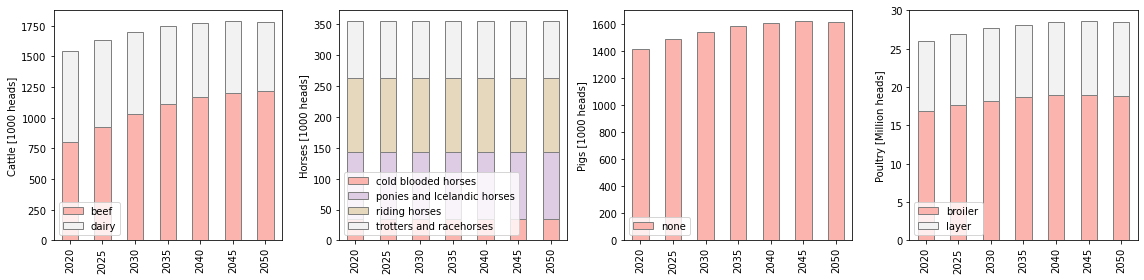

In [14]:
for scn in scenarios:
    years = scenarios[scn]['years']
    print(scn)
    
    # Number of animal heads
    plot_data = output.get_attr('A','heads',['species','breed']).loc[scn]

    fig, axs = plt.subplots(1,4, figsize=(16,4))

    for ax,sp in zip(axs,plot_data.columns.get_level_values('species').unique()):

        (
            (plot_data / (1000000 if sp=='poultry' else 1000))
            .xs(sp, level='species', axis=1)
            .plot(**style, ax = ax)
        )

        ax.set_ylabel(sp.capitalize() + (' [Million heads]' if sp=='poultry' else ' [1000 heads]'))
        ax.set_xlabel('')
        ax.legend(loc='lower left', bbox_to_anchor=(0, 0))
    
    plt.tight_layout()
    plt.show()

FAI


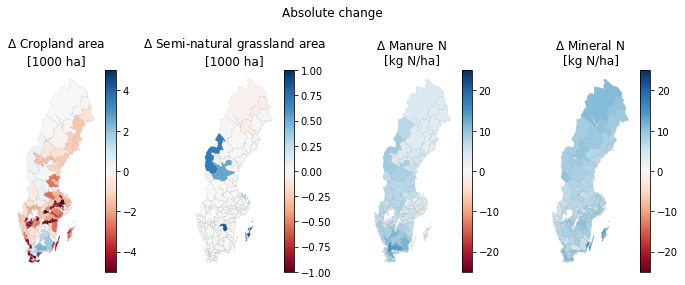

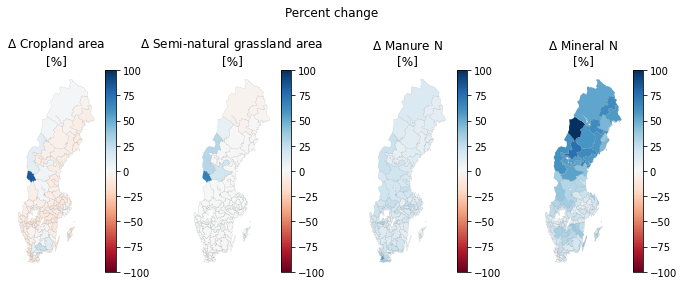

In [38]:
for scn in scenarios:
    years = scenarios[scn]['years']
    print(scn)
    
    y0 = output.loc[scn].index.get_level_values('year')[0]
    yend = output.loc[scn].index.get_level_values('year')[-1]

    # ABSOLUTE
    fig, axs = plt.subplots(1,4, figsize=(10,4))
    
    # LAND USE -------->
    plot_data = output.get_attr('C','area',{'crop':'land_use','region':None}).loc[scn]/1000
    plot_data = plot_data.loc[yend] - plot_data.loc[y0]
    # Cropland area --->
    ax = axs[0]
    plot.map_from_series(
        plot_data.loc['cropland'],
        cmap='RdBu',
        vmin=-5,
        vmax=5,
        edgecolor='grey',
        ax=ax
    )
    ax.set_title('$\Delta$ Cropland area\n[1000 ha]')
    ax.set_axis_off()

    # Grassland area --->
    ax = axs[1]
    plot.map_from_series(
        plot_data.loc['semi-natural grasslands'],
        cmap='RdBu',
        vmin=-1,
        vmax=1,
        edgecolor='grey',
        ax=ax
    )
    ax.set_title('$\Delta$ Semi-natural grassland area\n[1000 ha]')
    ax.set_axis_off()

    # Manure N application --->
    plot_data = output.get_attr('C','fertiliser.manure_N',{'crop':'land_use','region':None}).loc[scn,'cropland'] \
    / output.get_attr('C','area',{'crop':'land_use','region':None}).loc[scn,'cropland']
    plot_data = plot_data.loc[yend] - plot_data.loc[y0]
    
    ax = axs[2]
    plot.map_from_series(
        plot_data,
        cmap='RdBu',
        vmin=-25,
        vmax=25,
        edgecolor='grey',
        ax=ax
    )
    ax.set_title('$\Delta$ Manure N \n[kg N/ha]')
    ax.set_axis_off()

    # Mineral N application --->
    plot_data = output.get_attr('C','fertiliser.mineral_N',{'crop':'land_use','region':None}).loc[scn,'cropland'] \
    / output.get_attr('C','area',{'crop':'land_use','region':None}).loc[scn,'cropland']
    plot_data = plot_data.loc[yend] - plot_data.loc[y0]
    
    ax = axs[3]
    plot.map_from_series(
        plot_data,
        cmap='RdBu',
        vmin=-25,
        vmax=25,
        edgecolor='grey',
        ax=ax
    )
    ax.set_title('$\Delta$ Mineral N \n[kg N/ha]')
    ax.set_axis_off()

    
    plt.suptitle('Absolute change')
    plt.tight_layout()
    plt.show()

    # PERCENT
    fig, axs = plt.subplots(1,4, figsize=(10,4))
    
    # LAND USE -------->
    plot_data = output.get_attr('C','area',{'crop':'land_use','region':None}).loc[scn]/1000
    plot_data = (plot_data.loc[yend] - plot_data.loc[y0]) / plot_data.loc[y0] * 100
    # Cropland area --->
    ax = axs[0]
    plot.map_from_series(
        plot_data.loc['cropland'],
        cmap='RdBu',
        vmin=-100,
        vmax=100,
        edgecolor='grey',
        ax=ax
    )
    ax.set_title('$\Delta$ Cropland area\n[%]')
    ax.set_axis_off()

    # Grassland area --->
    ax = axs[1]
    plot.map_from_series(
        plot_data.loc['semi-natural grasslands'],
        cmap='RdBu',
        vmin=-100,
        vmax=100,
        edgecolor='grey',
        ax=ax
    )
    ax.set_title('$\Delta$ Semi-natural grassland area\n[%]')
    ax.set_axis_off()

    # Manure N application --->
    plot_data = output.get_attr('C','fertiliser.manure_N',{'crop':'land_use','region':None}).loc[scn,'cropland'] \
    / output.get_attr('C','area',{'crop':'land_use','region':None}).loc[scn,'cropland']
    plot_data = (plot_data.loc[yend] - plot_data.loc[y0]) / plot_data.loc[y0] * 100
    
    ax = axs[2]
    plot.map_from_series(
        plot_data,
        cmap='RdBu',
        vmin=-100,
        vmax=100,
        edgecolor='grey',
        ax=ax
    )
    ax.set_title('$\Delta$ Manure N \n[%]')
    ax.set_axis_off()

    # Mineral N application --->
    plot_data = output.get_attr('C','fertiliser.mineral_N',{'crop':'land_use','region':None}).loc[scn,'cropland'] \
    / output.get_attr('C','area',{'crop':'land_use','region':None}).loc[scn,'cropland']
    plot_data = (plot_data.loc[yend] - plot_data.loc[y0]) / plot_data.loc[y0] * 100
    
    ax = axs[3]
    plot.map_from_series(
        plot_data,
        cmap='RdBu',
        vmin=-100,
        vmax=100,
        edgecolor='grey',
        ax=ax
    )
    ax.set_title('$\Delta$ Mineral N \n[%]')
    ax.set_axis_off()
   
    
    plt.suptitle('Percent change')
    plt.tight_layout()
    plt.show()

FAI


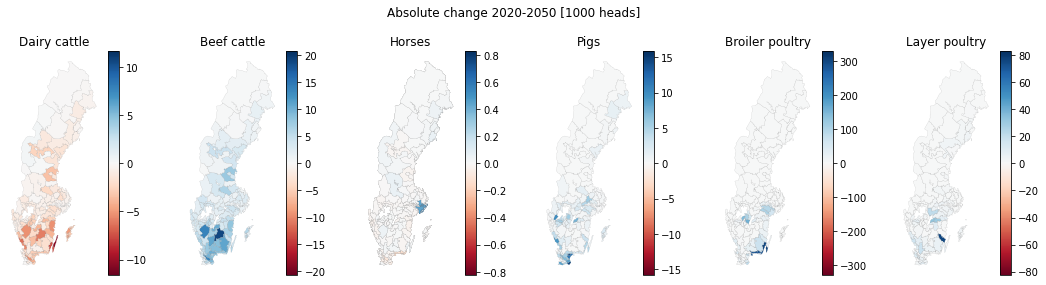

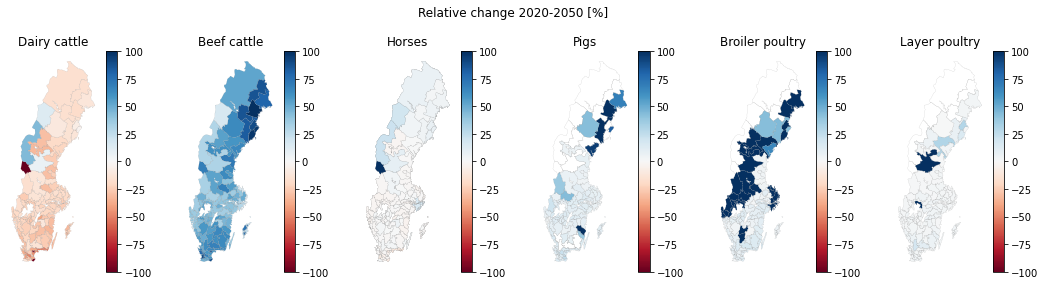

In [39]:
selection = {
    'Dairy cattle':('cattle','dairy'),
    'Beef cattle':('cattle','beef'),
    'Horses':('horses',slice(None)),
    'Pigs':('pigs',slice(None)),
    'Broiler poultry':('poultry','broiler'),
    'Layer poultry':('poultry','layer')
}

for scn in scenarios:
    print(scn)
    
    plot_data = output.get_attr('A','heads',['species','breed','region']).loc[scn]/1000
    plot_data_abs = (plot_data.loc['2050'] - plot_data.loc['2020']).sort_index()
    plot_data_prc = ((plot_data.loc['2050'] - plot_data.loc['2020']) / plot_data.loc['2020'] * 100).sort_index()
    
    # ABSOLUTE
    fig, axs = plt.subplots(1,len(selection), figsize=(len(selection)*2.5,4))
    for ax,sel in zip(axs,selection):
        d = plot_data_abs.loc[selection[sel]]
        lim = max(abs(d))
        plot.map_from_series(
            d,
            ax=ax,
            cmap='RdBu',
            vmin=-lim*1.1,
            vmax=lim*1.1,
            edgecolor='grey'
        )
        ax.axis('off')
        ax.set_title(sel)  
    plt.suptitle('Absolute change 2020-2050 [1000 heads]')
    plt.tight_layout()
    plt.show()
    
    # PERCENT
    fig, axs = plt.subplots(1,len(selection), figsize=(len(selection)*2.5,4))
    for ax,sel in zip(axs,selection):
        d = plot_data_prc.loc[selection[sel]]
        lim = max(abs(d))
        plot.map_from_series(
            d,
            ax=ax,
            cmap='RdBu',
            vmin=-100,
            vmax=100,
            edgecolor='grey'
        )
        ax.axis('off')
        ax.set_title(sel)
    plt.suptitle('Relative change 2020-2050 [%]')
    plt.tight_layout()
    plt.show()

### Output to ICBM
This is a work-in-progress interface to ICBM soil carbon modelling

In [41]:
icbm = cm.to_ICBM(output)

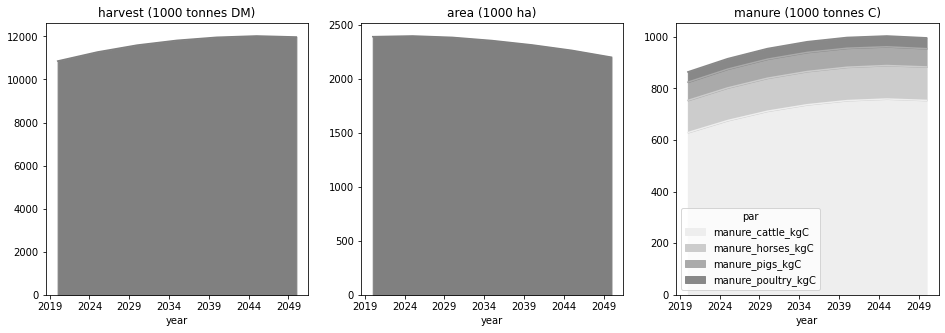

In [42]:
fig, axs = plt.subplots(1,3, figsize=(16,5))

ax=axs[0]
(icbm.groupby(['scn','year']).sum().droplevel('scn')['harvest_kgdm']/1000000).plot(kind='area', color='grey', ax=ax)
start, end = ax.get_xlim()
ax.xaxis.set_ticks(np.arange(start+0.5, end+0.5, 5))
ax.set_title('harvest (1000 tonnes DM)')

ax=axs[1]
(icbm.groupby(['scn','year']).sum().droplevel('scn')['area_ha']/1000).plot(kind='area', color='grey', ax=ax)
start, end = ax.get_xlim()
ax.xaxis.set_ticks(np.arange(start+0.5, end+0.5, 5))
ax.set_title('area (1000 ha)')

ax=axs[2]
(icbm.groupby(['scn','year']).sum().droplevel('scn').loc[:,'manure_cattle_kgC':]/1000000).plot(kind='area', color=['#eeeeee','#cccccc','#aaaaaa','#888888'], stacked=True, ax=ax)
start, end = ax.get_xlim()
ax.xaxis.set_ticks(np.arange(start+0.5, end+0.5, 5))
ax.set_title('manure (1000 tonnes C)')
plt.show()

In [20]:
icbm.to_csv('FAI_to_ICBM.csv')